In [26]:
#Manual Workflow Dataset Cleaning & Analysis 

#Import packages
import pandas as pd
import os
import matplotlib.pyplot as plt


#Import dataframe 
df = pd.read_csv("/Users/saadana/Downloads/manual_workflow.csv")

#Create a copy of the dataframe
df_clean = df.copy()

In [40]:
#Preview dataset

print(df_clean.shape)
print(df_clean.info())
print(df_clean.describe()) # there are invalid entries in manual minutes (ie. negative values)
                           # there are missing values in created_date, completed_date and error_flag columns
print(df_clean.head()) # there are inconsistent names in the task_type and error_flag columns 
print(df_clean.duplicated().sum()) #5000 duplicated rows were found 

(497184, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 497184 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   task_id          497184 non-null  object        
 1   staff_id         497184 non-null  object        
 2   department_id    497184 non-null  object        
 3   task_type        497184 non-null  object        
 4   created_date     480455 non-null  datetime64[ns]
 5   completed_date   480807 non-null  datetime64[ns]
 6   manual_minutes   497184 non-null  float64       
 7   error_flag       497184 non-null  object        
 8   system_used      497184 non-null  object        
 9   processing_days  464634 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(6)
memory usage: 41.7+ MB
None
                        created_date                 completed_date  \
count                         480455                         480807   
mean   2024-07

In [41]:
#Remove invalid data

#Remove duplicate rows
df_clean = df_clean.drop_duplicates()

#Remove missing date values
df = df.dropna(subset=['created_date', 'completed_date']) #remove missing dates 

In [42]:
#Convert dates to standardized format

df_clean['created_date'] = pd.to_datetime(df_clean['created_date'],errors='coerce')
df_clean['completed_date'] = pd.to_datetime(df_clean['completed_date'],errors='coerce')



In [43]:
#Standardize error flags column

#View unique error flags - inconsistent values were found 
print(df_clean["error_flag"].unique())

#Create a dictionary to map unique values to consistent values
error_map = {"Y": "Y",
    "Yes": "Y",
    "TRUE": "Y",
    "1": "Y",
    "Error": "Y",
    "N": "N",
    "No": "N",
    "FALSE": "N",
    "0": "N"
}

#Map values to error_flag column
df_clean["error_flag"] = (df_clean["error_flag"].replace(error_map))

#Convert missing values to 'unknown'
df_clean['error_flag'] = df_clean['error_flag'].map(error_map).fillna("Unknown")

#Check if error flags are consistent 
print(df_clean["error_flag"].unique())

['N' 'Y' 'Unknown']


In [64]:
#Standardize task names column

#View unique task names - inconsistent names were found 
print(sorted(df_clean["task_type"].unique()))

#Clean column to remove whitespace and convert to lowercase
df_clean["task_type"] = (
    df_clean["task_type"]
    .str.strip()
    .str.lower()
)

#Create dictionary with unique task names to consistent names
task_mapping = {
    # Excel Reporting
    "spreadsheet": "Excel Report",
    "excel report": "Excel Report",
    "manual report": "Excel Report",
    "excel": "Excel Report",

    # Claims
    "claim": "Claim Review",
    "claim review": "Claim Review",
    "claims review": "Claim Review",

    # Patient Follow-Ups
    "patient follow-up": "Patient Follow-Up",
    "patient followup": "Patient Follow-Up",
    "followup": "Patient Follow-Up",
    "follow-up": "Patient Follow-Up",

    # Lab Follow-Ups
    "lab": "Lab Follow-Up",
    "lab followup": "Lab Follow-Up",
    "lab follow-up": "Lab Follow-Up",
    "diagnostic followup": "Lab Follow-Up",

    # Data Entry
    "data entry": "Data Entry",
    "data-entry": "Data Entry",
    "entry": "Data Entry",
    "manual entry": "Data Entry",

    # Scheduling
    "scheduling": "Scheduling",
    "schedule": "Scheduling",
    "sched": "Scheduling",
    "booking": "Scheduling",
    "billing review": "Billing Review"
}

#Map task names
df_clean["task_type"] = (df_clean["task_type"].replace(task_mapping))

#Check if task names are consistent 
print(sorted(df_clean["task_type"].unique()))


['Billing Review', 'Claim Review', 'Data Entry', 'Excel Report', 'Lab Follow-Up', 'Patient Follow-Up', 'Scheduling']
['Billing Review', 'Claim Review', 'Data Entry', 'Excel Report', 'Lab Follow-Up', 'Patient Follow-Up', 'Scheduling']


In [45]:
#Remove invalid manual minutes

df_clean = df_clean[(df_clean['manual_minutes'] >= 0) & (df_clean['manual_minutes'] <= 720)]


In [46]:
#Create new "Processing Days" column 

df_clean['processing_days'] = (df_clean['completed_date'] - df_clean['created_date']).dt.days 



In [47]:
#Save cleaned dataset as a new csv file
from pathlib import Path

downloads_path = Path.home() / "Downloads"
os.chdir(downloads_path)

df_clean.to_csv("manual_workflow_clean.csv", index=False)

In [67]:
#Analysis 

#Find minutes spent on each task 
task_time = df_clean.groupby('task_type')['manual_minutes'].sum().sort_values(ascending = False)

#Top most time-consuming tasks 
print(task_time)



task_type
Excel Report         9122437.2
Claim Review         4459498.0
Patient Follow-Up    3337613.0
Data Entry           2513704.6
Scheduling           1696747.9
Lab Follow-Up        1387657.8
Billing Review         91012.0
Name: manual_minutes, dtype: float64


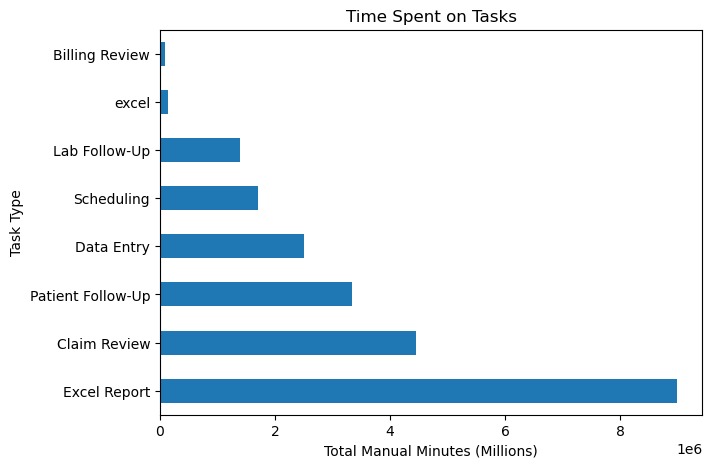

In [49]:
#Create horizontal barplot 

plt.figure(figsize=(7,5))
task_time.plot(kind='barh')

plt.title('Time Spent on Tasks')
plt.xlabel('Total Manual Minutes (Millions)')
plt.ylabel('Task Type')

plt.show()

In [68]:
#Find most common task types
task_frequency = (df_clean['task_type'].value_counts())

#Top most common tasks
print(task_frequency)


task_type
Excel Report         124552
Patient Follow-Up     89031
Claim Review          87841
Data Entry            84824
Scheduling            69284
Lab Follow-Up         39857
Billing Review         1795
Name: count, dtype: int64


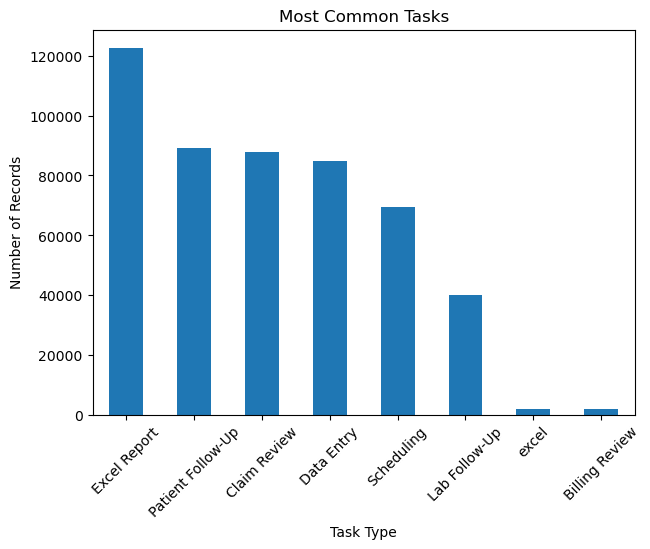

In [51]:
#Create barplot of most common task types

plt.figure(figsize=(7,5))
task_frequency.plot(kind='bar')

plt.title("Most Common Tasks")
plt.xlabel("Task Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.show()

In [52]:
#Find most common systems used 
system_frequency = (df_clean['system_used'].value_counts())

#Top Systems Used
print(system_frequency)

system_used
Excel             188773
EMR               149238
Billing System     69442
Email              59778
Paper Form         29953
Name: count, dtype: int64


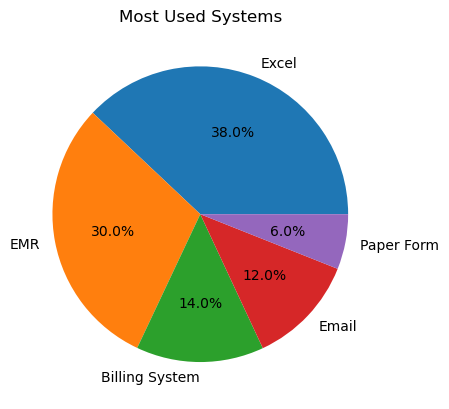

In [53]:
#Create piechart of most common systems 

plt.pie(system_frequency,labels=system_frequency.index,autopct="%1.1f%%")

plt.title("Most Used Systems")

plt.show()

In [69]:
#Average time for task completion

avg_processing = (df_clean.groupby('task_type')['manual_minutes'].mean().sort_values(ascending=False))
print(avg_processing)

task_type
Excel Report         73.241997
Claim Review         50.767842
Billing Review       50.703064
Patient Follow-Up    37.488212
Lab Follow-Up        34.815912
Data Entry           29.634356
Scheduling           24.489751
Name: manual_minutes, dtype: float64


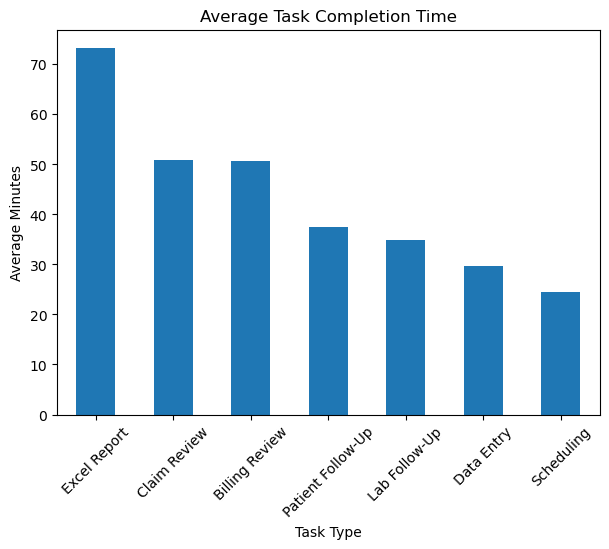

In [70]:
#Create barplot of average minutes to complete tasks 
plt.figure(figsize=(7,5))
avg_processing.plot(kind='bar')

plt.title('Average Task Completion Time')
plt.xlabel('Task Type')
plt.ylabel('Average Minutes')

plt.xticks(rotation=45)
plt.show()

In [73]:
#Find total time consumed by each system 
system_minutes = (df_clean.groupby('system_used')['manual_minutes'].sum().sort_values(ascending=False))
print(system_minutes)

system_used
Excel             8599928.4
EMR               6765807.0
Billing System    3162338.3
Email             2719121.3
Paper Form        1361475.5
Name: manual_minutes, dtype: float64


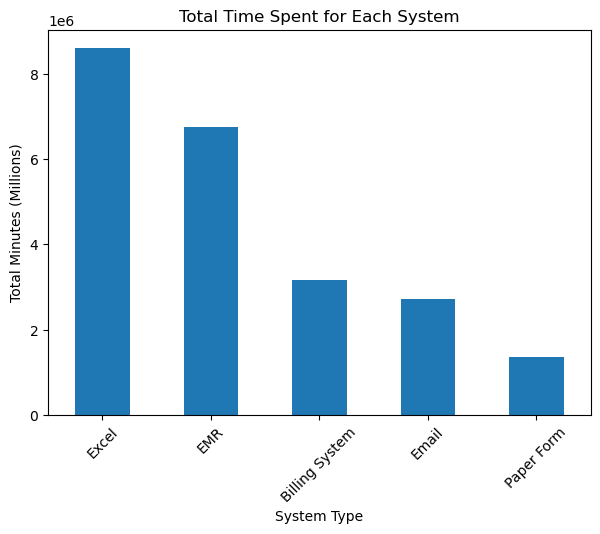

In [74]:
#Create barplot of time spent on each system

plt.figure(figsize=(7,5))
system_minutes.plot(kind='bar')

plt.title('Total Time Spent for Each System')
plt.xlabel('System Type')
plt.ylabel('Total Minutes (Millions)')

plt.xticks(rotation=45)
plt.show()

In [61]:
#Find processing days for each system 

system_processing = (df_clean.groupby("system_used")["processing_days"].mean().sort_values(ascending=False))

print(system_processing)

system_used
EMR               2.282194
Excel             2.278278
Billing System    2.276771
Paper Form        2.275427
Email             2.269751
Name: processing_days, dtype: float64


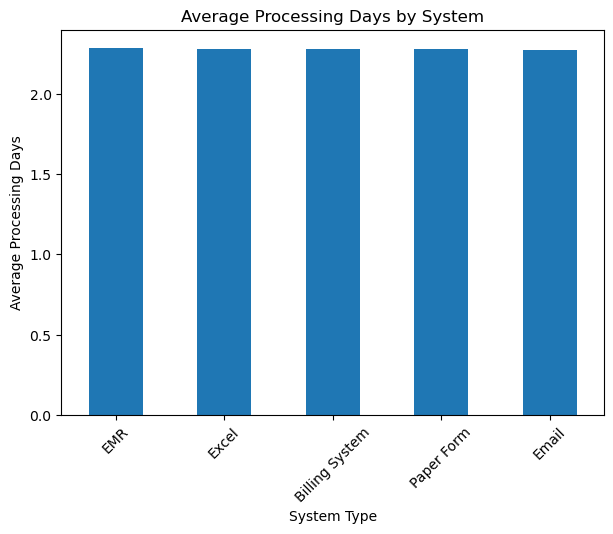

In [62]:
#Create barplot of processing days for each system 

plt.figure(figsize=(7,5))

system_processing.plot(kind='bar')

plt.title('Average Processing Days by System')
plt.xlabel('System Type')
plt.ylabel('Average Processing Days')

plt.xticks(rotation=45)
plt.show()

In [78]:
#Create summary chart for task types

summary = pd.DataFrame({
    "Task Count":
        df_clean.groupby("task_type").size(),

    "Average Manual Minutes":
        df_clean.groupby("task_type")["manual_minutes"].mean().round(2),

    "Average Processing Days":
        df_clean.groupby("task_type")["processing_days"].mean().round(2)
})

#Sort data by average manual minutes
summary.sort_values(by="Average Manual Minutes",ascending=False)



                Average Manual Minutes  Average Processing Days
system_used                                                    
Excel                            45.56                     2.28
Billing System                   45.54                     2.28
Email                            45.49                     2.27
Paper Form                       45.45                     2.28
EMR                              45.34                     2.28


In [80]:
# Create summary chart for system used 

system_summary = pd.DataFrame({
    "Average Manual Minutes": 
        df_clean.groupby("system_used")["manual_minutes"].mean().round(2),

    "Average Processing Days": 
        df_clean.groupby("system_used")["processing_days"].mean().round(2)
})

# Sort data by average manual minutes 
system_summary.sort_values(by="Average Manual Minutes", ascending=False)


,Average Manual Minutes,Average Processing Days
system_used,,
Excel,45.56,2.28
Billing System,45.54,2.28
Email,45.49,2.27
Paper Form,45.45,2.28
EMR,45.34,2.28
